# 삼양사 식품부문 매출 × 경제지표 상관관계 분석

DART 공시 원문(`data/dart_xml/`)에서 삼양사 식품부문 매출액을 직접 파싱해서 추출하고,
`Food_Company_Sales` 대시보드가 이미 수집해 둔 32개 경제지표(PostgreSQL/Neon)와 대조한다.

구성:
1. DART 공시에서 식품부문 매출 추출
2. 누적치를 분기 단위로 역산
3. DB에서 관련 경제지표 로드
4. 레벨 / 변화율 / 시차(lag) 세 가지 각도로 상관관계 계산

> **주의**: 표본이 15~18개 분기로 작다. 상관계수는 확정된 관계가 아니라 참고용 신호로 해석할 것.

## 0. 환경 설정

In [ ]:
import re
import sys
from pathlib import Path
from datetime import date

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

sys.path.append(str(Path("../../RAG").resolve()))  # dart_parser.py가 있는 폴더
import dart_parser
import eda_utils  # 계열사 노트북 공통 로직 (같은 mandu/Eda 폴더)

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트 (다른 OS라면 폰트명 교체)

In [ ]:
DART_DIR = Path("../../RAG/data/dart_xml")
TARGET_COMPANIES = {"(주)삼양사", "삼양사"}  # 계열사 중 삼양사 표기 변형

# 지표 DB(DATABASE_URL)는 Steam_Sales/dashboard/backend/.env 에 있다
DASHBOARD_ENV = Path("../../dashboard/backend/.env")
load_dotenv(DASHBOARD_ENV)

## 1. DART 공시에서 삼양사 식품부문 매출 추출

사업/반기/분기보고서의 "나. 사업부문별 재무정보" 표에서 `식품 | 매출액 | ...` 행만 정규식으로 뽑는다.
이 값은 **그 보고서의 회계연도 시작일부터 보고 기준일까지의 누적 매출**이다
(분기보고서 Q1=3개월, 반기보고서=6개월, 9개월보고서=9개월, 사업보고서=12개월 누적).

In [ ]:
FOOD_ROW_RE = re.compile(r"식품\s*\|\s*매출액:?\s*\|\s*([\d,]+)")

cum_df, failed = eda_utils.extract_cumulative_metric(
    DART_DIR, TARGET_COMPANIES, FOOD_ROW_RE, value_col="food_revenue_cum",
)
cum_df

## 2. 누적 매출을 분기 단위로 역산

같은 회계연도 안에서 연속된 보고서의 누적치를 차분하면 그 구간만의 매출이 나온다
(Q2 = 반기누적 − Q1, Q3 = 9개월누적 − 반기누적, Q4 = 연간누적 − 9개월누적).

**주의**: 그 해의 첫 보고서가 원래 1분기(약 90일)보다 훨씬 긴 기간을 다루고 있으면
(= 앞선 분기 보고서가 파싱에서 빠진 경우), 그 값은 여러 분기가 뭉친 것이라 단일 구간
매출로 쓰면 이상치가 된다. 이 경우는 구간으로 만들지 않고 기준점만 갱신한다.

In [ ]:
revenue_df = eda_utils.cumulative_to_quarterly(cum_df, cum_col="food_revenue_cum", out_col="food_revenue")
print(f"{len(revenue_df)}개 구간 (단위: 백만원)")
revenue_df

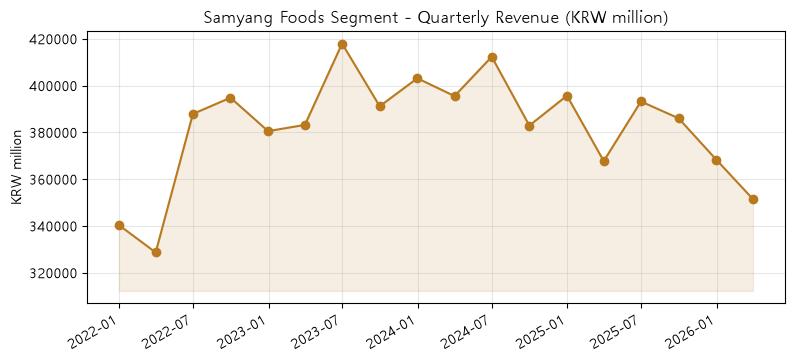

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(revenue_df.index, revenue_df["food_revenue"], marker="o", color="#B8791F")
ax.fill_between(revenue_df.index, revenue_df["food_revenue"], revenue_df["food_revenue"].min() * 0.95, alpha=0.12, color="#B8791F")
ax.set_title("Samyang Foods Segment - Quarterly Revenue (KRW million)")
ax.set_ylabel("KRW million")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

## 3. DB에서 경제지표 로드

`Food_Company_Sales/dashboard/backend`가 이미 수집해 둔 `indicator_points` 테이블에서
식품 원자재/수요 관련 지표만 가져온다.

In [ ]:
from sqlalchemy import create_engine
import os

engine = create_engine(os.environ["DATABASE_URL"], pool_pre_ping=True)

TARGETS = {
    "market_yfinance": ["옥수수", "대두", "대두유", "설탕(원당)", "커피", "밀",
                        "원달러환율", "WTI유가", "달러인덱스", "KOSPI", "구리(전기동)",
                        "브렌트유", "천연가스", "원유로환율", "미국국채10년"],
    "fao_food_price_index": ["Food Price Index", "Cereals", "Oils", "Sugar", "Dairy", "Meat"],
    "livestock_prices": ["한우", "돼지", "닭", "계란", "우유"],
    "rice_price": ["산지쌀가격(원/20kg)"],
    "price_index_kr_us": ["한국", "미국"],
    "retail_sales": ["백화점", "대형마트", "면세점"],
    "policy_rates": ["한국", "미국", "중국", "일본"],
    "samyang_stock_prices": ["삼양사"],  # 자사 주가 - 매출보다 먼저/나중에 반응하는지 확인용
}

all_series = eda_utils.load_indicator_series(engine, TARGETS)
print(f"{len(all_series)}개 지표 시계열 로드")

## 4. 기간별 지표 평균과 매출 정렬

각 매출 구간(`period_from` ~ `period_to`)에 대해, 그 구간 안 지표 값의 평균을 계산한다.

In [ ]:
aligned = eda_utils.align_indicators_to_periods(revenue_df, "food_revenue", all_series)
aligned.head()

## 5. 레벨 기준 상관관계

구간 평균 지표값과 그 구간 식품 매출액을 그대로 비교한다.
장기 추세를 공유하는 지표끼리는 실제 연관이 없어도 상관계수가 높게 나올 수 있으니
(가짜 상관), 다음 절의 변화율 기준과 함께 봐야 한다.

In [ ]:
level_corr = eda_utils.corr_table(aligned, all_series, "food_revenue")
level_corr.head(15)

In [ ]:
eda_utils.plot_top_correlations(level_corr, "Level correlation with food-segment revenue (top 15 by |r|)")

## 6. 전기 대비 변화율(%) 기준 상관관계

레벨 대신 구간 대비 변화율끼리 비교해서 장기 추세의 영향을 줄인다.

In [ ]:
pct = aligned.drop(columns=["period_from"]).pct_change().dropna(how="all")
pct_corr = eda_utils.corr_table(pct, all_series, "food_revenue", min_n=6)
pct_corr.head(15)

## 7. 시차(Lag) 분석

지표가 t−L 구간 시점, 매출은 t 구간 시점일 때의 레벨 상관계수. 원자재 가격 변화가
몇 분기 뒤 매출에 반영되는지 보기 위함이다.

> **다중비교 주의**: 지표 수 × lag(0~3) 조합을 모두 훑어서 최댓값을 고르는 방식이라,
> 표본이 15~18개뿐인 상황에서는 우연히 강한 값이 나올 수 있다. 여기서 나온 결과는
> 확정된 관계가 아니라 **검증해볼 가설 후보**로 취급할 것.

In [ ]:
level_df = aligned.drop(columns=["period_from"])
lag_df = eda_utils.lag_correlation_table(level_df, all_series, "food_revenue")
lag_df.head(15)

In [ ]:
eda_utils.plot_lag_heatmap(lag_df, "Lag correlation (indicator at t-L vs revenue at t)")

## 결론 및 한계

- 가장 근거 있는 신호: **설탕 원자재 가격(yfinance 설탕 선물, FAO Sugar 지수) → 2개 분기 뒤 매출**의
  양(+)의 상관관계. 서로 독립된 두 소스에서 같은 방향·같은 시차로 재현됨.
- 나머지 상위 항목(정책금리, 구리, 환율 등)은 식품 매출과의 직접적 연결고리가 약해
  공통 거시 추세를 반영한 대리 상관일 가능성이 크다.
- 표본이 15~18개 분기로 작고, 2020년~2021년 상반기 공시 5건은 표 형식이 달라 파싱에서
  제외됐다. 표본을 늘리려면 이 구간의 파싱 로직을 보강해야 한다 (`FOOD_ROW_RE` 정규식이
  이 시기 문서의 표 레이아웃과 맞지 않음).
- lag 분석은 지표 수 × lag 조합을 모두 탐색해 최댓값을 고르는 방식이라 다중비교 문제가 있다.
  통계적으로 확정된 관계가 아니라 가설 후보로 취급할 것.